In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("task2_cleaned_weather_data.xlsx")
df["time"] = pd.to_datetime(df["time"])

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 1830 rows × 13 columns


In [2]:
# A day is "Rainy" if precipitation > 1mm, otherwise "Dry"
df["rain_label"] = (df["precipitation_sum"] > 1).astype(int)

# 0 = Dry, 1 = Rainy
label_counts = df["rain_label"].value_counts()
print("Label Distribution:")
print(f"  Dry days   (0) : {label_counts[0]} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"  Rainy days (1) : {label_counts[1]} ({label_counts[1]/len(df)*100:.1f}%)")

Label Distribution:
  Dry days   (0) : 977 (53.4%)
  Rainy days (1) : 853 (46.6%)


In [3]:
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "windspeed_10m_max",
    "relative_humidity_2m_mean",
    "month",
    "day_of_year",
]

target = "rain_label"

X = df[features]
y = df[target]

print(f"Features : {features}")
print(f"X shape  : {X.shape}")

Features : ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'windspeed_10m_max', 'relative_humidity_2m_mean', 'month', 'day_of_year']
X shape  : (1830, 7)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 1464
Testing samples  : 366


In [5]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [6]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_pred_prob)

print("=" * 45)
print("  MODEL EVALUATION")
print("=" * 45)
print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  AUC Score: {auc:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Dry", "Rainy"]))

  MODEL EVALUATION
  Accuracy : 0.8005 (80.1%)
  AUC Score: 0.8999

Classification Report:
              precision    recall  f1-score   support

         Dry       0.89      0.73      0.80       202
       Rainy       0.73      0.89      0.80       164

    accuracy                           0.80       366
   macro avg       0.81      0.81      0.80       366
weighted avg       0.82      0.80      0.80       366



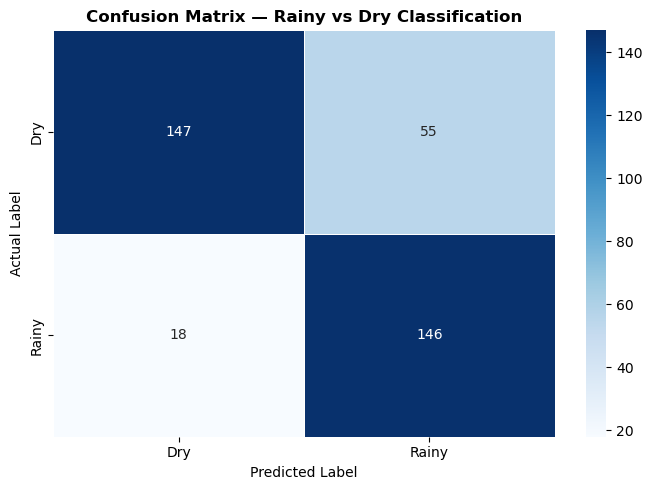

In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Dry", "Rainy"],
            yticklabels=["Dry", "Rainy"],
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix — Rainy vs Dry Classification", fontweight='bold')

plt.tight_layout()
plt.savefig("chart5b_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

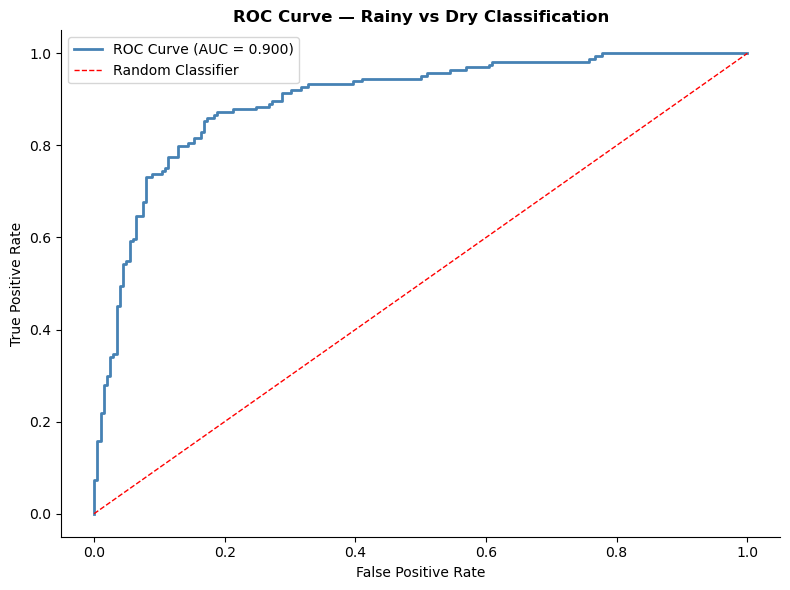

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, 
        label=f"ROC Curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Rainy vs Dry Classification", fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart5b_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

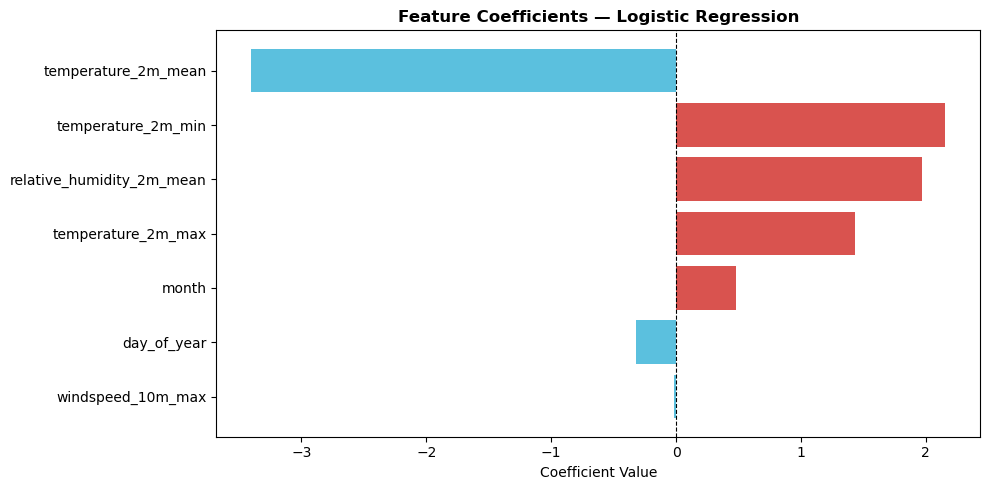

In [9]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d9534f" if c > 0 else "#5bc0de" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Feature Coefficients — Logistic Regression", fontweight='bold')
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("chart5b_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
results_df = pd.DataFrame(X_test, columns=features)
results_df["Actual_Label"]     = y_test.values
results_df["Predicted_Label"]  = y_pred
results_df["Predicted_Label"]  = results_df["Predicted_Label"].map({0: "Dry", 1: "Rainy"})
results_df["Actual_Label"]     = results_df["Actual_Label"].map({0: "Dry", 1: "Rainy"})
results_df["Rain_Probability"] = y_pred_prob.round(4)

results_df.to_excel("task5b_classification_results.xlsx", index=False)
print("Saved: task5b_classification_results.xlsx")

Saved: task5b_classification_results.xlsx
